# Main script

## Part (i): loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
import rioxarray
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

def save_to_geotiff(data, x_coord, y_coord, filename):
    # Create an xarray DataArray
    da = xr.DataArray(data, coords=[('y', y_coord), ('x', x_coord)])
    
    # Save to GeoTIFF using rioxarray
    da.rio.to_raster(filename)

%load_ext autoreload
%autoreload 2

data_path  = os.getenv('DATA_PATH')
param_path = os.getenv('PARAM_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
X_filename           = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename           = 'trainingAll4D_Ns_sim_masked_standardized.mat'
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


X_data           = scipy.io.loadmat(folder + X_filename)
Y_data           = scipy.io.loadmat(folder + Y_filename)
flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized = X_data['Eb_standardized']
Ns_standardized = Y_data['Ns_standardized_masked']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Ns_standardized:', Ns_standardized.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized: (256, 256, 1, 1042)
Shape of Ns_standardized: (256, 256, 1, 1042)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


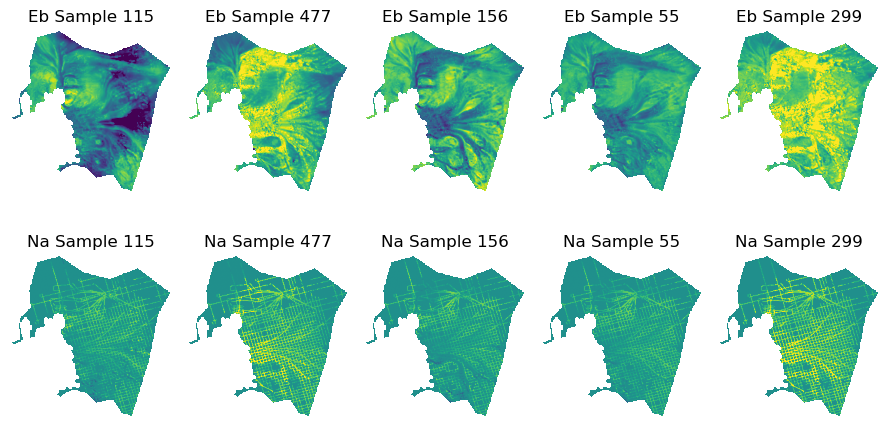

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))
md.load_sim_data(Eb_standardized, Ns_standardized, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

## Part (ii): inspecting data dimension with PCA

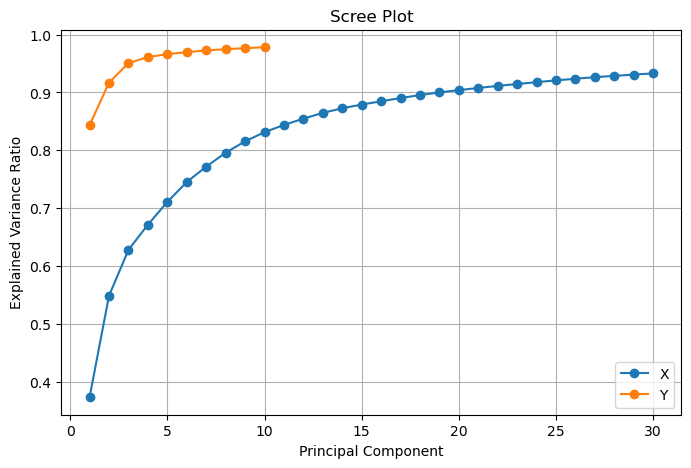

In [3]:
md.pca_scree(n_component_x=30, n_component_y=10)

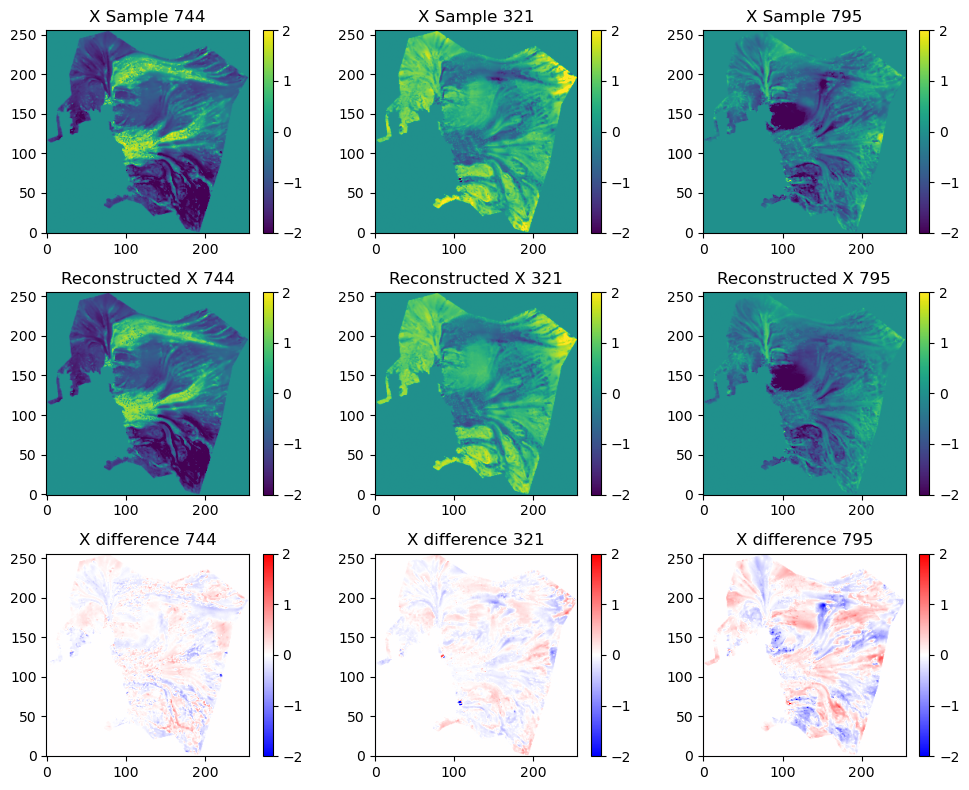

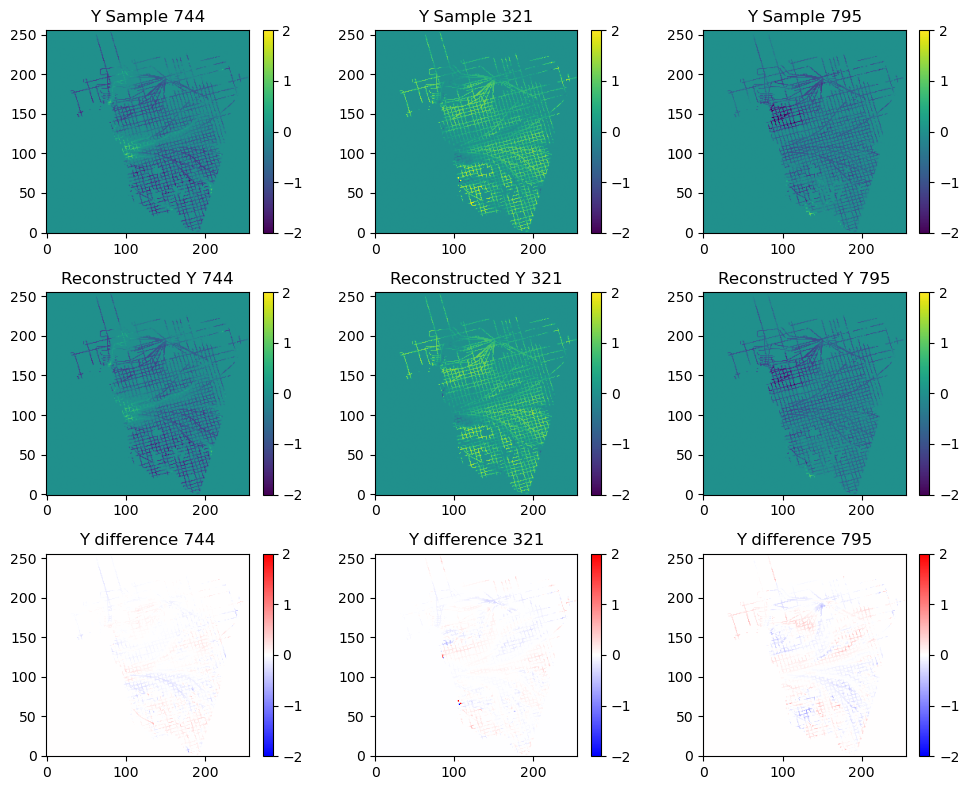

In [4]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

## Part (iii): Dimension reduction and 

Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.09 seconds.


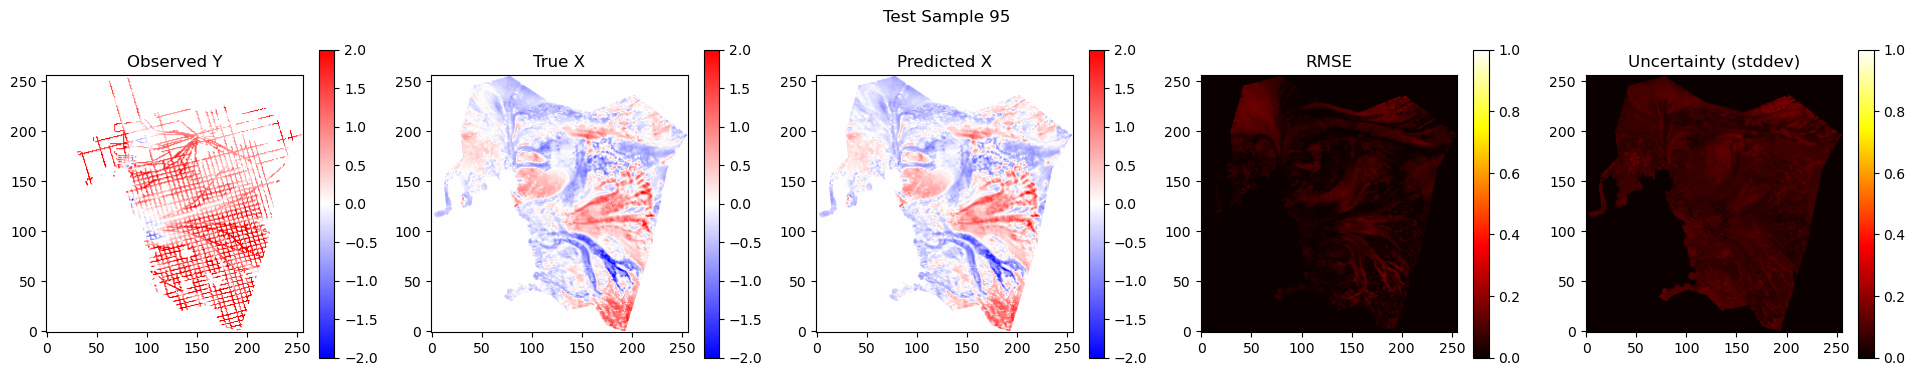

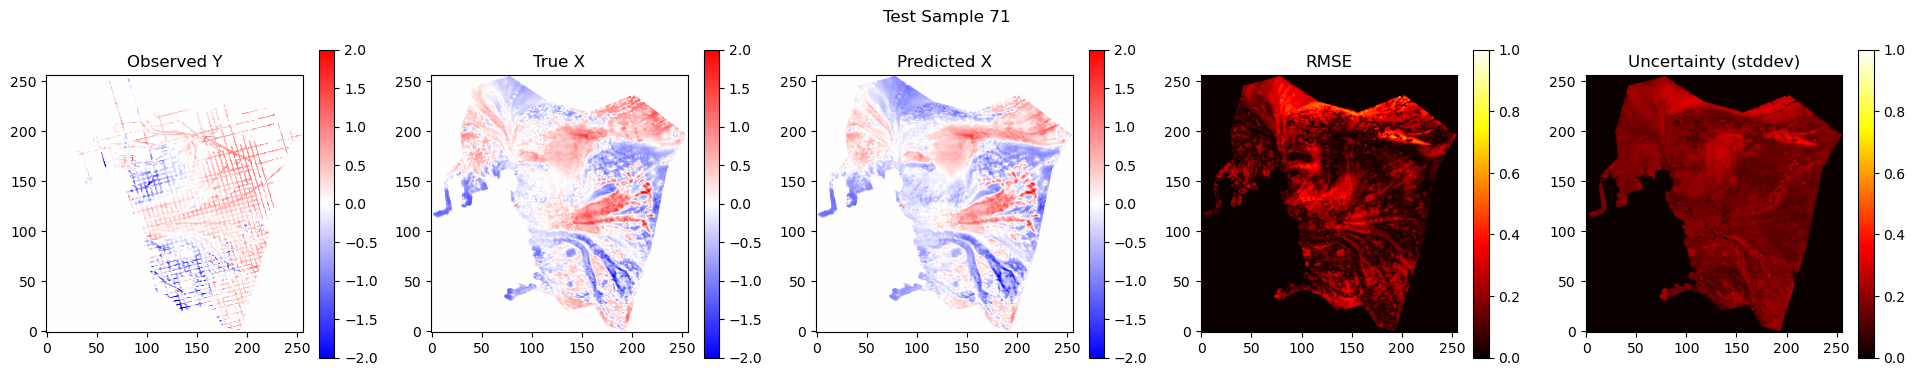

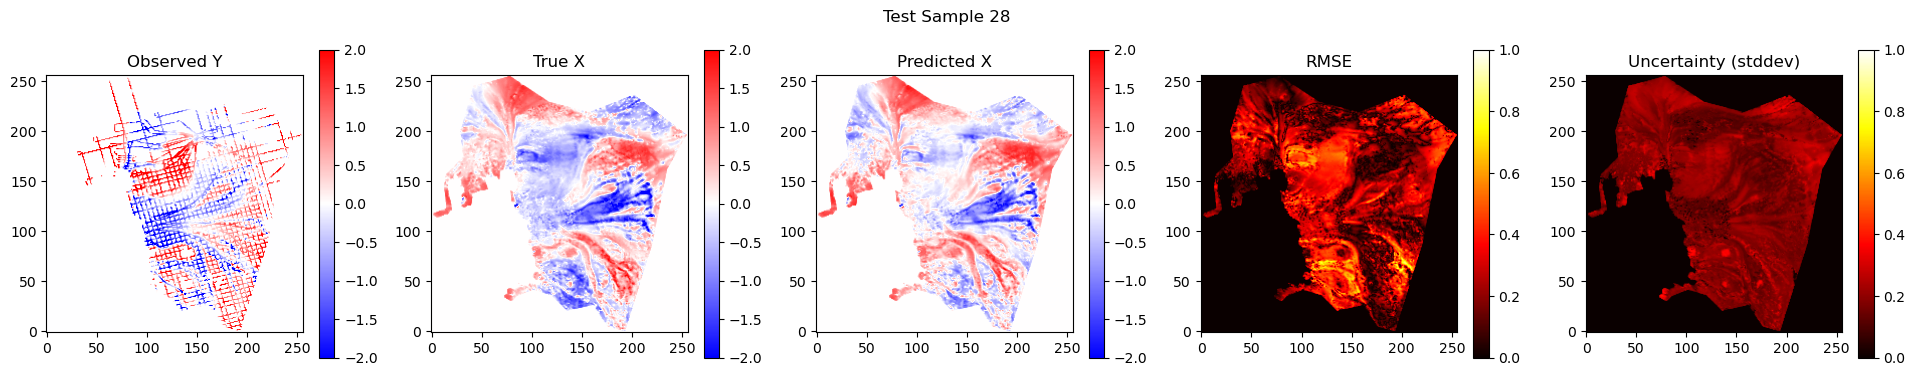

In [ ]:
# reduce dim with PCA. 
md.reduce(n_component_x=25, n_component_y=8)

# split data and train a GMM
md.data_split(train_ratio=0.8, validation_ratio=0.1, test_ratio=0.1)
md.train_gmm_XY(n_components=25)
md.plot_gmm_samples(n_samples=3)

shape of Y_obs: (256, 256)
Using relaxation z-score standardization with epsilon = 0.262291780650704


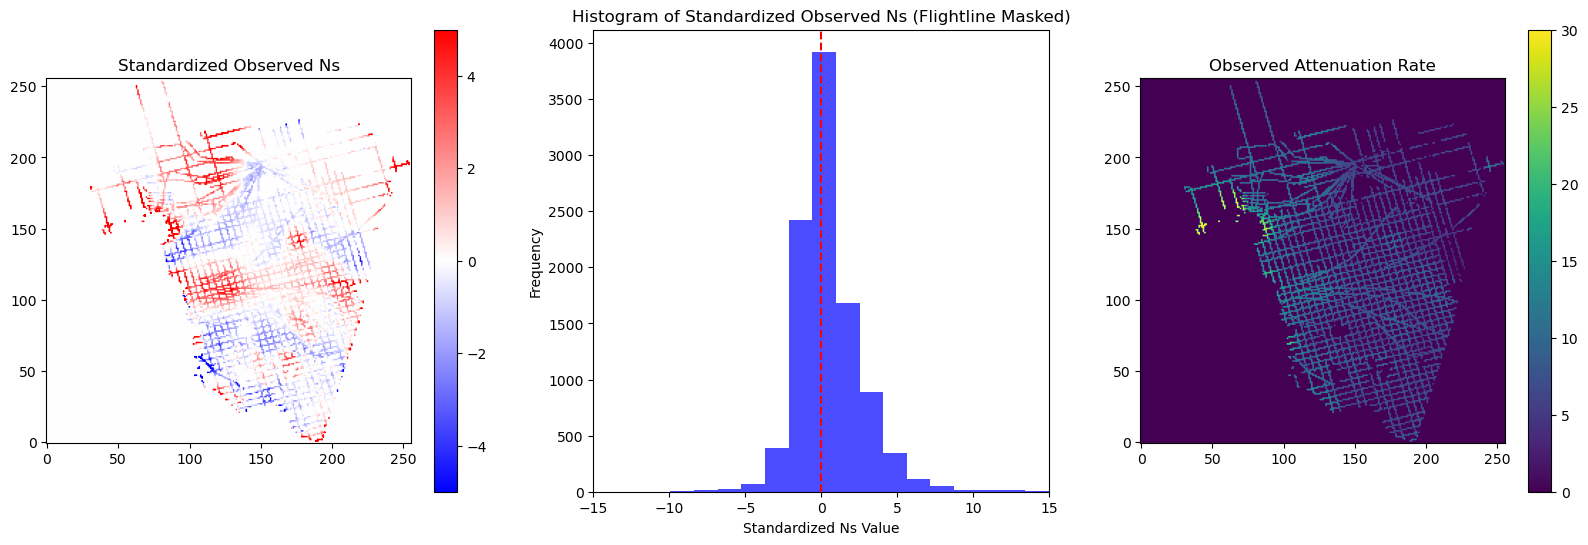

In [147]:
md.load_obs_data(atten_rate_avg)

Density at init: [0.40260132]
 Likelihood: 0.976, Prior: 0.910
 Likelihood: 0.967, Prior: 0.975
 Likelihood: 0.975, Prior: 0.910
 Likelihood: 0.974, Prior: 0.910
 Likelihood: 0.973, Prior: 0.911
 Likelihood: 0.973, Prior: 0.911
 Likelihood: 0.971, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.913
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
 Likelihood: 0.970, Prior: 0.912
Optimization success: True
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations: 20
Function evaluations: 24
Final objective: 1.8821


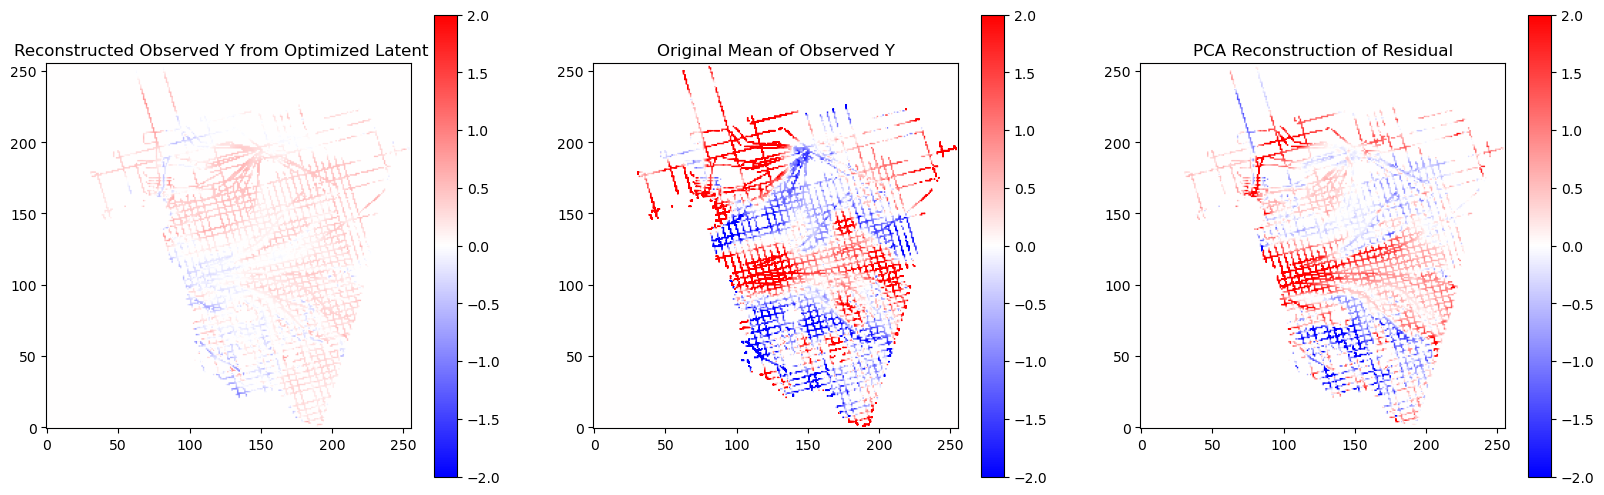

first 5x5 block of cov_obs_latent:
[[23458.57884569  3904.39025387  -308.05643261  1322.27438157]
 [ 3904.39025387  8024.09058257  -488.72278333  2097.75076152]
 [ -308.05643261  -488.72278333   884.14638355  -165.51255742]
 [ 1322.27438157  2097.75076152  -165.51255742   963.12008174]]
min eigenvalue: 59.137108291985555
conditioned indices are:  [0 1 2 3 4 5 6 7]


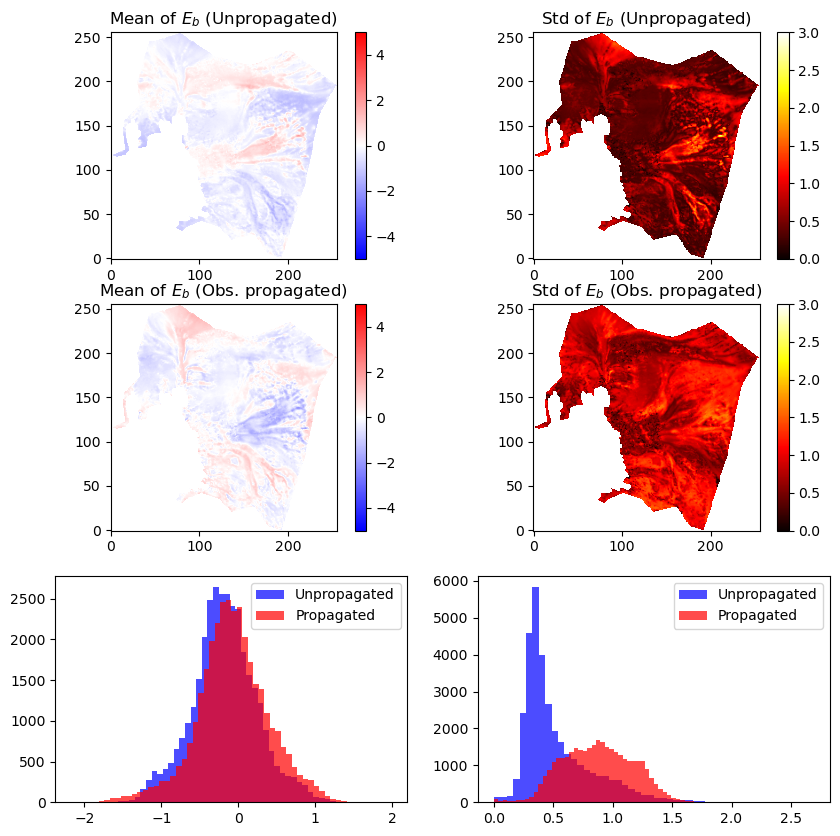

In [169]:
beta_prior = 1
lambda1, lambda2 = 3, 3
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

# Finding Posterior

In [ ]:
from src.ice import compute_pmp

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H).reshape(md.nx, md.ny)

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

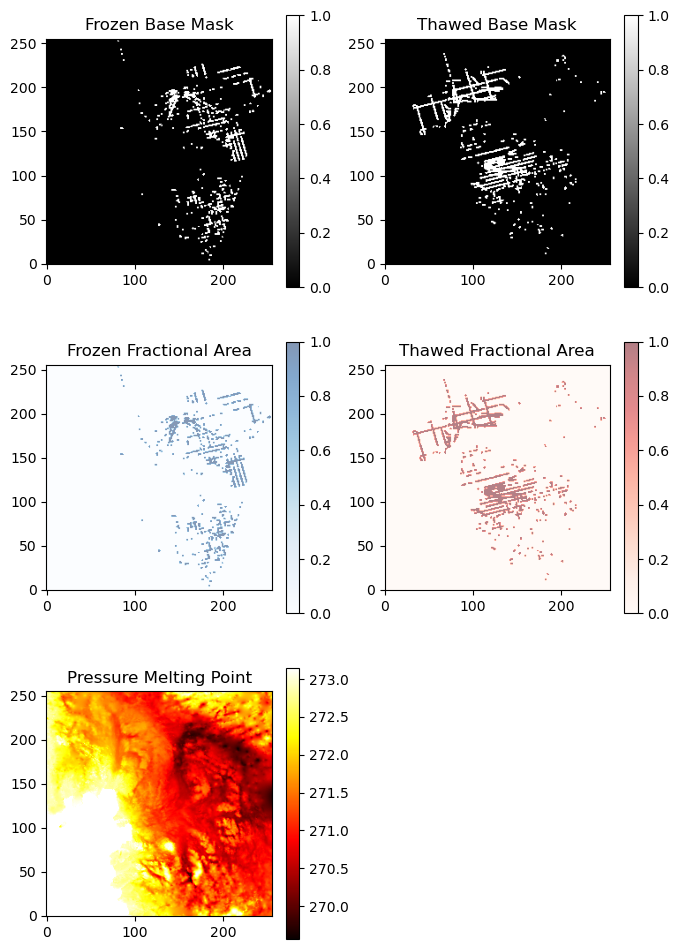

In [160]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 4307.2487
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 4192.4163
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 4178.6576
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 4164.4263
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 4163.8686
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 4163.7615
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 4163.7628
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 4163.7655
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 4163.7681
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 4163.7736
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 4163.7872
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 4163.7834
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 4

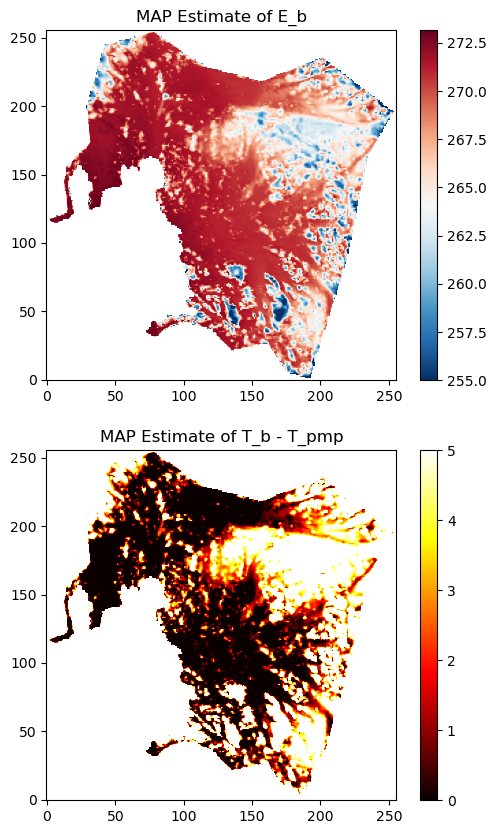

In [166]:
beta_posterior = 1
md.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5)